In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns, warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

rfm = pd.read_csv('../data/processed/rfm_clustered.csv')
print(f"RFM data: {len(rfm):,} customers")
print(f"Segments: {rfm['Segment'].value_counts().to_dict()}")

RFM data: 5,350 customers
Segments: {'Champions': 1361, 'Lost': 1347, 'Loyal Customers': 1108, 'At-Risk': 741, 'New Customers': 402, 'Potential Loyalists': 322, 'Big Spenders': 69}


In [3]:
seg_summary = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',    'mean'),
    Avg_Frequency = ('Frequency',  'mean'),
    Avg_Monetary  = ('Monetary',   'mean'),
    Total_Revenue = ('Monetary',   'sum')
).round(1)

seg_summary['Revenue_%'] = (seg_summary['Total_Revenue'] /
                             seg_summary['Total_Revenue'].sum() * 100).round(1)
seg_summary['Customer_%'] = (seg_summary['Customers'] /
                              seg_summary['Customers'].sum() * 100).round(1)

seg_summary = seg_summary.sort_values('Total_Revenue', ascending=False)
print(seg_summary.to_string())
seg_summary.to_csv('../data/processed/segment_summary.csv')
print("Saved ✅")

                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_%  Customer_%
Segment                                                                                                       
Champions                 1361         20.8           15.4        7190.1      9785714.1       68.0        25.4
Loyal Customers           1108         80.4            5.5        1928.8      2137108.7       14.9        20.7
At-Risk                    741        372.2            5.0        1893.6      1403129.5        9.8        13.9
Lost                      1347        462.6            1.2         311.7       419869.0        2.9        25.2
New Customers              402         28.7            1.5         895.6       360022.2        2.5         7.5
Big Spenders                69        323.4            1.6        2329.8       160757.2        1.1         1.3
Potential Loyalists        322        111.6            1.4         380.9       122634.2        0.9         6.0
S

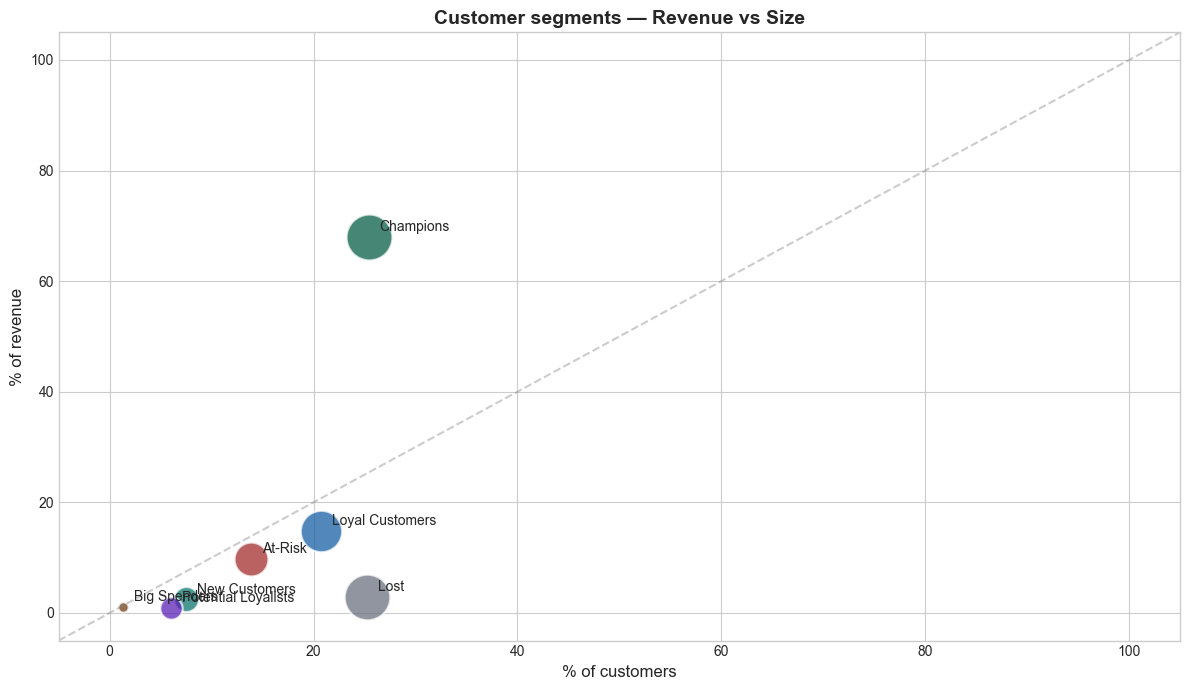

Saved ✅


In [4]:
colors = {'Champions':'#065f46','Loyal Customers':'#185fa5',
          'At-Risk':'#a32d2d','Potential Loyalists':'#5b21b6',
          'Big Spenders':'#713f12','New Customers':'#0f766e',
          'Lost':'#6b7280'}

fig, ax = plt.subplots(figsize=(12,7))
for seg, row in seg_summary.iterrows():
    ax.scatter(row['Customer_%'], row['Revenue_%'],
               s=row['Customers']*0.8,
               c=colors.get(seg,'gray'),
               alpha=0.75, edgecolors='white', linewidth=1.5)
    ax.annotate(seg,
                xy=(row['Customer_%'], row['Revenue_%']),
                xytext=(8,4), textcoords='offset points',
                fontsize=10, fontweight='500')

ax.axline((0,0),(100,100), linestyle='--', color='gray', alpha=0.4)
ax.set_xlabel('% of customers', fontsize=12)
ax.set_ylabel('% of revenue', fontsize=12)
ax.set_title('Customer segments — Revenue vs Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/segment_revenue_bubble.png', dpi=150)
plt.show()
print("Saved ✅")

In [6]:
strategies = pd.DataFrame([
    {'Segment':'Champions',
     'Priority':'High',
     'Strategy':'Loyalty & referral program',
     'Actions':'VIP membership, referral rewards, early access',
     'Channel':'Email, App notification',
     'Expected_Impact':'Increase referrals by 20%',
     'Estimated_ROI':'High'},
    {'Segment':'At-Risk',
     'Priority':'Critical',
     'Strategy':'Win-back campaign',
     'Actions':'Personalised email, 15% discount, survey',
     'Channel':'Email, Phone, SMS',
     'Expected_Impact':'Recover 25% of at-risk customers',
     'Estimated_ROI':'Very High'},
    {'Segment':'Loyal Customers',
     'Priority':'High',
     'Strategy':'Tier upgrade push',
     'Actions':'Points multiplier, anniversary gift',
     'Channel':'Email, App',
     'Expected_Impact':'Move 30% to Champions tier',
     'Estimated_ROI':'High'},
    {'Segment':'Potential Loyalists',
     'Priority':'Medium',
     'Strategy':'Engagement & upsell',
     'Actions':'Recommendations, bundle offers',
     'Channel':'Email, Retargeting ads',
     'Expected_Impact':'Increase order frequency 15%',
     'Estimated_ROI':'Medium'},
    {'Segment':'New Customers',
     'Priority':'Medium',
     'Strategy':'Onboarding & conversion',
     'Actions':'Welcome series, second purchase discount',
     'Channel':'Email, Push notification',
     'Expected_Impact':'Convert 40% to repeat buyers',
     'Estimated_ROI':'Medium'},
    {'Segment':'Big Spenders',
     'Priority':'High',
     'Strategy':'VIP & frequency boost',
     'Actions':'Account manager, exclusive catalogue',
     'Channel':'Phone, Personal email',
     'Expected_Impact':'Double order frequency',
     'Estimated_ROI':'Very High'},
    {'Segment':'Lost',
     'Priority':'Low',
     'Strategy':'Last-chance re-engagement',
     'Actions':'Final email with 25% discount, then suppress',
     'Channel':'Email only',
     'Expected_Impact':'Recover 5-10% at low cost',
     'Estimated_ROI':'Low'}
])

strategies.to_csv('../data/processed/retention_strategies.csv', index=False)
print(strategies[['Segment','Priority','Strategy','Expected_Impact']].to_string(index=False))
print("Saved ✅")

            Segment Priority                   Strategy                  Expected_Impact
          Champions     High Loyalty & referral program        Increase referrals by 20%
            At-Risk Critical          Win-back campaign Recover 25% of at-risk customers
    Loyal Customers     High          Tier upgrade push       Move 30% to Champions tier
Potential Loyalists   Medium        Engagement & upsell     Increase order frequency 15%
      New Customers   Medium    Onboarding & conversion     Convert 40% to repeat buyers
       Big Spenders     High      VIP & frequency boost           Double order frequency
               Lost      Low  Last-chance re-engagement        Recover 5-10% at low cost
Saved ✅


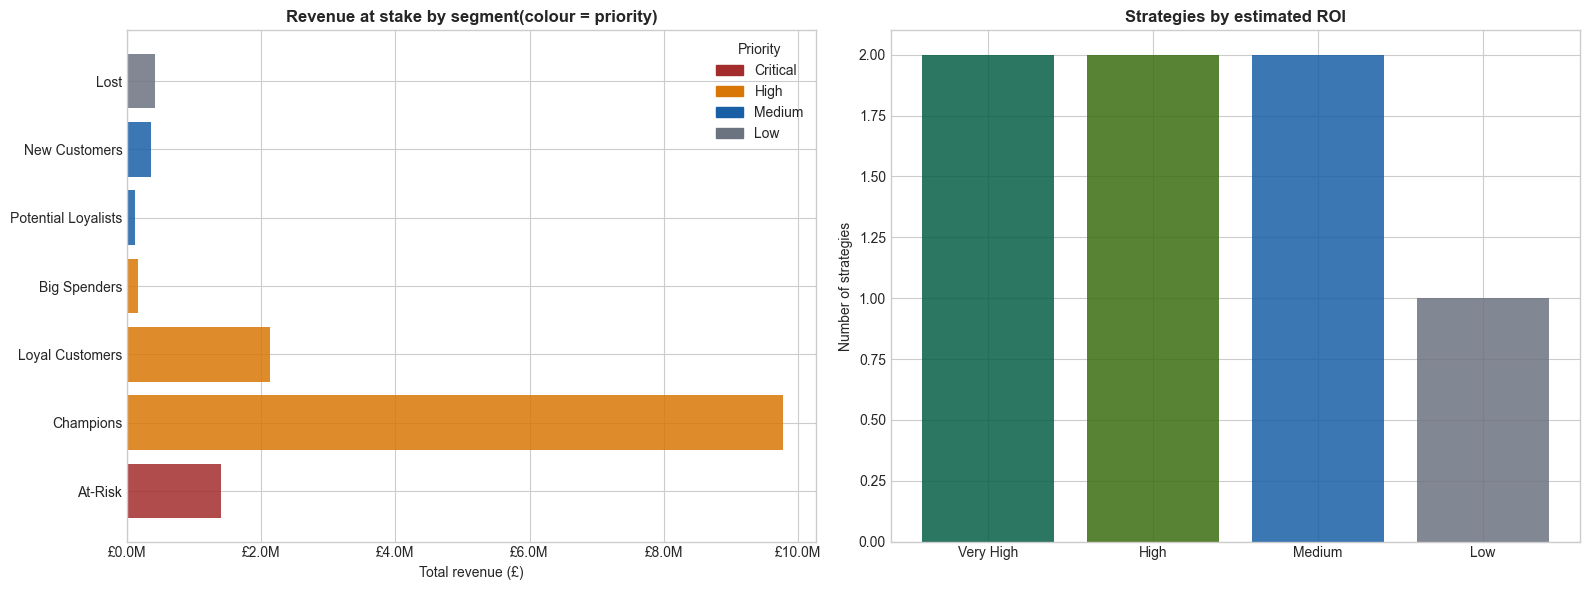

Saved ✅


In [9]:
fig, axes = plt.subplots(1,2,figsize=(16,6))

priority_colors = {'Critical':'#a32d2d','High':'#d97706',
                   'Medium':'#185fa5','Low':'#6b7280'}
strat_sorted = strategies.sort_values(['Priority'],
    key=lambda x: x.map({'Critical':0,'High':1,'Medium':2,'Low':3}))

axes[0].barh(
    strat_sorted['Segment'],
    strat_sorted['Segment'].map(rfm.groupby('Segment')['Monetary'].sum()),
    color=[priority_colors[p] for p in strat_sorted['Priority']],
    alpha=0.85)
axes[0].set_title('Revenue at stake by segment(colour = priority)',fontweight='bold')
axes[0].set_xlabel('Total revenue (£)')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))

patches = [mpatches.Patch(color=c, label=l)
           for l,c in priority_colors.items()]
axes[0].legend(handles=patches, title='Priority')

roi_counts = strategies['Estimated_ROI'].value_counts().reindex(
    ['Very High','High','Medium','Low'])
axes[1].bar(roi_counts.index, roi_counts.values,
            color=['#065f46','#3b6d11','#185fa5','#6b7280'], alpha=0.85)
axes[1].set_title('Strategies by estimated ROI', fontweight='bold')
axes[1].set_ylabel('Number of strategies')

plt.tight_layout()
plt.savefig('../reports/figures/retention_priority.png', dpi=150)
plt.show()
print("Saved ✅")

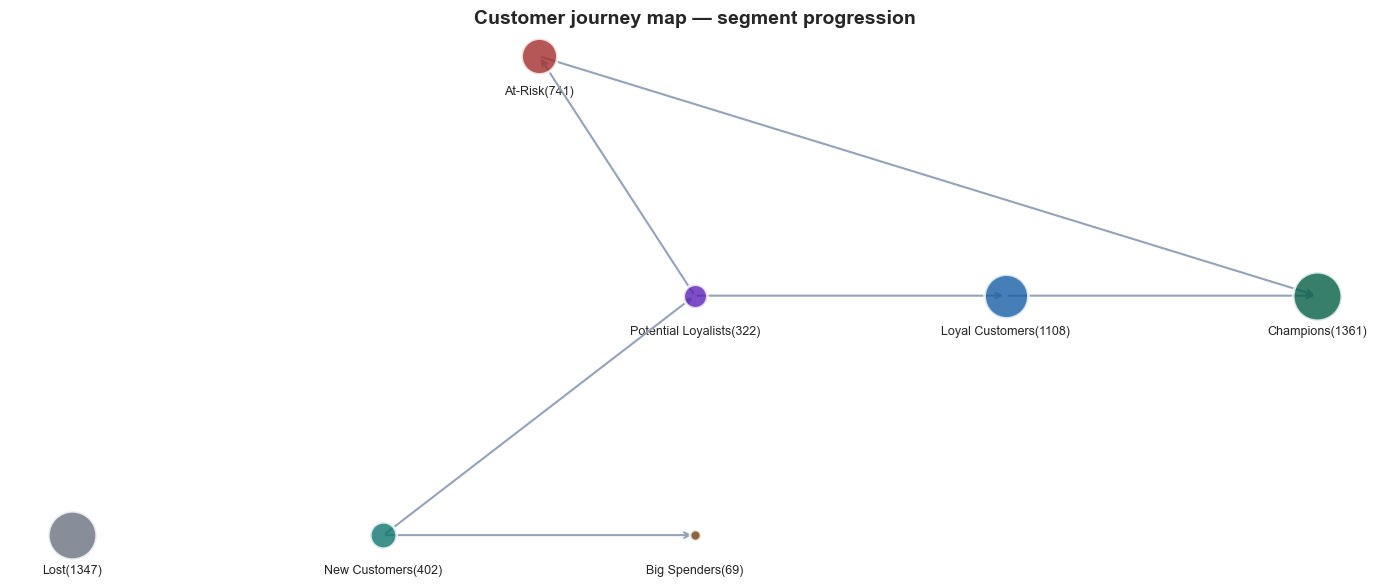

Saved ✅


In [11]:
fig, ax = plt.subplots(figsize=(14,6))

segment_flow = [
    ('Lost',               0.5, 1, '#6b7280'),
    ('New Customers',      2.5, 1, '#0f766e'),
    ('Potential Loyalists',4.5, 2, '#5b21b6'),
    ('Big Spenders',       4.5, 1, '#713f12'),
    ('At-Risk',            3.5, 3, '#a32d2d'),
    ('Loyal Customers',    6.5, 2, '#185fa5'),
    ('Champions',          8.5, 2, '#065f46'),
]

for name, x, y, color in segment_flow:
    count = rfm['Segment'].value_counts().get(name, 0)
    ax.scatter(x, y, s=count*0.9, c=color, alpha=0.8,
               edgecolors='white', linewidth=2, zorder=5)
    ax.annotate(f'{name}({count})', xy=(x,y),
                xytext=(0,-28), textcoords='offset points',
                ha='center', fontsize=9, fontweight='500')

arrow = dict(arrowstyle='->', color='#94a3b8', lw=1.5)
for s,e in [((2.5,1),(4.5,2)),((2.5,1),(4.5,1)),
            ((4.5,2),(6.5,2)),((6.5,2),(8.5,2)),
            ((4.5,2),(3.5,3)),((3.5,3),(8.5,2))]:
    ax.annotate('', xy=e, xytext=s, arrowprops=arrow)

ax.set_title('Customer journey map — segment progression',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../reports/figures/customer_journey_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

## Day 11 — Retention strategies

### Strategy summary
| Segment | Priority | Strategy | ROI |
|---------|----------|----------|-----|
| At-Risk | Critical | Win-back campaign | Very High |
| Big Spenders | High | VIP & frequency boost | Very High |
| Champions | High | Loyalty & referral | High |
| Loyal Customers | High | Tier upgrade push | High |
| Potential Loyalists | Medium | Engagement & upsell | Medium |
| New Customers | Medium | Onboarding & conversion | Medium |
| Lost | Low | Last-chance re-engagement | Low |

### Key business insights
- At-Risk: £1.99M revenue at risk — highest urgency
- Champions (  25.4% customers) → 68% revenue — protect
- New Customers: highest growth potential
- Lost: reallocate budget to At-Risk instead